In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve
import joblib
from sklearn.preprocessing import StandardScaler

In [2]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P","p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates','Lb_ETA','Jpsi_ETA', 'p_ETA','pim_ETA']

In [3]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [4]:
#Preselection data.
signal_data = pd.read_pickle('data24_armenteros.pkl')
adding_data = pd.read_pickle('data24_armenteros_add.pkl')
signal_data = pd.concat([signal_data,adding_data],axis='columns')

#Creates a new variables like the Cos()...
sum_CHI2 = signal_data['Lb_CHI2']+signal_data['L_CHI2']+signal_data['Jpsi_CHI2']
angle = np.arccos((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_angle = ((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_xi_L = ((signal_data['p_PX']*signal_data['L_PX']+signal_data['p_PY']*signal_data['L_PY']+signal_data['p_PZ']*signal_data['L_PZ'])/(signal_data['p_P']*signal_data['L_P']))
cos_xi_Lb = ((signal_data['p_PX']*signal_data['Lb_PX']+signal_data['p_PY']*signal_data['Lb_PY']+signal_data['p_PZ']*signal_data['Lb_PZ'])/(signal_data['p_P']*signal_data['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
signal_data['SUMCHI2'] = sum_CHI2
signal_data['Theta_P'] = angle
signal_data['Cos_theta_P'] = cos_angle
signal_data['Cos_xi_LP'] = cos_xi_L
signal_data['Cos_xi_LbP'] = cos_xi_Lb
signal_data['xi_LP'] = xi_LbP
signal_data['xi_LbP'] = xi_LP


signal_data


/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,pim_TRACK_POS_CLOSESTTOBEAM_X,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1077.975830,5846.956055,2974.502686,54863.386719,1776.397949,4.123077,0.005935,0.002314,0.997817,1.207904,...,-1746.7484,-215.8711,7895.8999,1.332619,0.140961,0.990081,0.999991,0.999902,0.014029,0.004257
1,1077.976562,5313.719238,3112.583496,58726.832031,1343.211792,4.470844,0.122067,0.009861,0.997888,1.222700,...,-1700.6754,505.1554,7826.0996,1.834390,0.127805,0.991844,0.999985,0.999979,0.006496,0.005426
2,1078.187256,6402.193359,3093.716309,18753.294922,2738.893555,2.611505,0.071255,0.009010,0.984698,1.317595,...,-1685.1663,-605.9817,7826.0996,8.643069,0.336862,0.943797,0.999327,0.999409,0.034373,0.036701
3,1078.331421,5060.589355,3078.505615,36252.464844,492.338257,4.992107,1.107087,0.028151,0.996496,1.103896,...,-1684.7295,-23.0286,7826.0996,24.885163,0.171750,0.985287,0.999998,0.999966,0.008250,0.002072
4,1078.344971,5300.834473,2953.872803,26179.085938,1636.410034,3.464616,1.147581,0.034740,0.992858,1.206773,...,-1658.7753,-189.1307,7895.8999,5.839044,0.227141,0.974314,1.000000,0.999871,0.016058,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385520,1499.999146,5465.837891,3116.906006,68869.664062,1651.937012,4.423246,0.240755,0.012574,0.999810,1.170818,...,1605.0896,-302.4525,7895.8994,37.424356,0.094939,0.995497,0.999515,0.999125,0.041827,0.031148
2385521,1499.999268,5057.749512,3105.656494,37938.269531,3193.528564,3.166201,2.272352,0.042266,0.986553,1.228708,...,1619.1001,225.9496,7826.0991,23.769515,0.165611,0.986318,0.999625,0.994184,0.107904,0.027388
2385522,1499.999634,6379.979980,3111.542480,38214.558594,2022.875732,3.631062,2.339109,0.063037,0.997769,1.338594,...,1627.0600,429.3525,7826.0991,42.082629,0.162117,0.986888,0.999794,0.997756,0.067000,0.020283
2385523,1499.999756,6493.334473,3065.772461,27737.134766,2734.924072,3.007334,0.421790,0.024650,0.999892,1.357072,...,1807.2089,-422.2669,7826.0991,26.433014,0.223562,0.975114,0.999879,0.999713,0.023974,0.015564


In [5]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")



mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_background = mc_background_merge.query(preselection_cut_mc)


#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LbP
mc_signal['xi_LbP'] = xi_LP

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")
mc_signal_background = mc_signal_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal_background['Lb_CHI2']+mc_signal_background['L_CHI2']+mc_signal_background['Jpsi_CHI2']
angle = np.arccos((mc_signal_background['mum_PX']*mc_signal_background['mup_PX']+mc_signal_background['mum_PY']*mc_signal_background['mup_PY']+mc_signal_background['mum_PZ']*mc_signal_background['mup_PZ'])/(mc_signal_background['mum_P']*mc_signal_background['mup_P']))
cos_angle = ((mc_signal_background['mum_PX']*mc_signal_background['mup_PX']+mc_signal_background['mum_PY']*mc_signal_background['mup_PY']+mc_signal_background['mum_PZ']*mc_signal_background['mup_PZ'])/(mc_signal_background['mum_P']*mc_signal_background['mup_P']))
cos_xi_L = ((mc_signal_background['p_PX']*mc_signal_background['L_PX']+mc_signal_background['p_PY']*mc_signal_background['L_PY']+mc_signal_background['p_PZ']*mc_signal_background['L_PZ'])/(mc_signal_background['p_P']*mc_signal_background['L_P']))
cos_xi_Lb = ((mc_signal_background['p_PX']*mc_signal_background['Lb_PX']+mc_signal_background['p_PY']*mc_signal_background['Lb_PY']+mc_signal_background['p_PZ']*mc_signal_background['Lb_PZ'])/(mc_signal_background['p_P']*mc_signal_background['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal_background['SUMCHI2'] = sum_CHI2
mc_signal_background['Theta_P'] = angle
mc_signal_background['Cos_theta_P'] = cos_angle
mc_signal_background['Cos_xi_LP'] = cos_xi_L
mc_signal_background['Cos_xi_LbP'] = cos_xi_Lb
mc_signal_background['xi_LP'] = xi_LbP
mc_signal_background['xi_LbP'] = xi_LP

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_5138/722157848.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_5138/722157848.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_5138/722157848.py:41: PerformanceWarning: DataFrame is highly fragme

In [6]:
#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LbP
mc_signal['xi_LbP'] = xi_LP

#Creates a new variables like the Cos()...
sum_CHI2 = mc_background['Lb_CHI2']+mc_background['L_CHI2']+mc_background['Jpsi_CHI2']
angle = np.arccos((mc_background['mum_PX']*mc_background['mup_PX']+mc_background['mum_PY']*mc_background['mup_PY']+mc_background['mum_PZ']*mc_background['mup_PZ'])/(mc_background['mum_P']*mc_background['mup_P']))
cos_angle = ((mc_background['mum_PX']*mc_background['mup_PX']+mc_background['mum_PY']*mc_background['mup_PY']+mc_background['mum_PZ']*mc_background['mup_PZ'])/(mc_background['mum_P']*mc_background['mup_P']))
cos_xi_L = ((mc_background['p_PX']*mc_background['L_PX']+mc_background['p_PY']*mc_background['L_PY']+mc_background['p_PZ']*mc_background['L_PZ'])/(mc_background['p_P']*mc_background['L_P']))
cos_xi_Lb = ((mc_background['p_PX']*mc_background['Lb_PX']+mc_background['p_PY']*mc_background['Lb_PY']+mc_background['p_PZ']*mc_background['Lb_PZ'])/(mc_background['p_P']*mc_background['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_background['SUMCHI2'] = sum_CHI2
mc_background['Theta_P'] = angle
mc_background['Cos_theta_P'] = cos_angle
mc_background['Cos_xi_LP'] = cos_xi_L
mc_background['Cos_xi_LbP'] = cos_xi_Lb
mc_background['xi_LP'] = xi_LbP
mc_background['xi_LbP'] = xi_LP


/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_5138/3356383861.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_5138/3356383861.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Theta_P'] = angle
/tmp/javeser/ipykernel_5138/3356383861.py:13: SettingWithCopyWarning: 
A value is

In [7]:
model = CatBoostClassifier().load_model("new_BDT_full_range")
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob1'] = signal_MVA_probs

data24= pd.read_pickle('data24_training.pkl')

data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
signal_data['EVENTNUMBER'] = data24['EVENTNUMBER']
signal_data['p_PID_P'] = data24['p_PID_P']
signal_data['SUMCHI2'] = data24['SUMCHI2']

data24_selected_chi2  = signal_data[signal_data.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==signal_data['SUMCHI2']].drop_duplicates('EVENTNUMBER')
data24_candidates  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

[[9.93731492e-01 6.26850812e-03]
 [9.99960236e-01 3.97641776e-05]
 [9.99987489e-01 1.25106092e-05]
 ...
 [1.00000000e+00 3.17364427e-10]
 [1.00000000e+00 5.74227775e-13]
 [9.99993244e-01 6.75641951e-06]]


In [8]:
model = CatBoostClassifier().load_model("new_BDT_full_range")
prob = model.predict_proba(mc_signal_background)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_signal_background['prob1'] = signal_MVA_probs

[[9.99972492e-01 2.75083522e-05]
 [1.05047828e-02 9.89495217e-01]
 [1.71655123e-04 9.99828345e-01]
 ...
 [9.99999996e-01 3.87098696e-09]
 [9.99894284e-01 1.05715953e-04]
 [2.30082351e-02 9.76991765e-01]]


/tmp/javeser/ipykernel_5138/1264657750.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal_background['prob1'] = signal_MVA_probs
/tmp/javeser/ipykernel_5138/1264657750.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_background['prob1'] = signal_MVA_probs


In [9]:
model = CatBoostClassifier().load_model("new_BDT_full_range")
prob = model.predict_proba(mc_signal)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_signal['prob1'] = signal_MVA_probs

[[1.05047828e-02 9.89495217e-01]
 [1.71655123e-04 9.99828345e-01]
 [2.31189836e-02 9.76881016e-01]
 ...
 [3.59823952e-01 6.40176048e-01]
 [7.89607219e-04 9.99210393e-01]
 [2.30082351e-02 9.76991765e-01]]


/tmp/javeser/ipykernel_5138/420460028.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['prob1'] = signal_MVA_probs
/tmp/javeser/ipykernel_5138/420460028.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['prob1'] = signal_MVA_probs


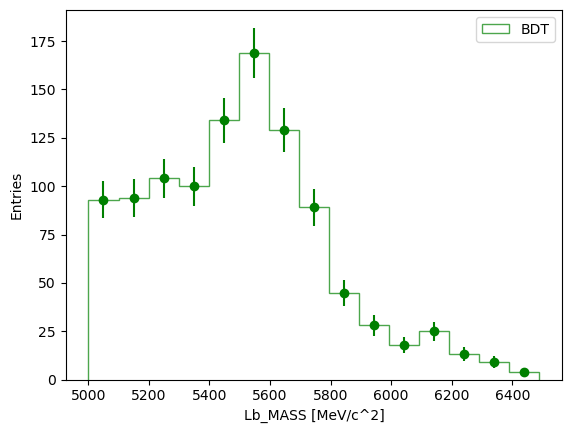

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()

# Plot histograms
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob1 > 0.99)')['Lb_MASS'], bins=15, label='BDT', color='green', alpha=0.7, histtype='step')
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='green',
    # label='Binary Data',
    drawstyle='steps-mid'
)

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [11]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# # Create the figure and axes
# fig, ax = plt.subplots()

# density = 'True'

# bins = np.linspace(5000, 6400, 50)
# bin_centres = 0.5 * (bins[1:] + bins[:-1])/1000

# # Plot histograms
# # hist1, bins1, _ = axes.plot(signal_data.query('(prob1 > 0.99)')['Lb_MASS'], bins=num_bins, label='Data', color='green', alpha=0.7, histtype='step', density=density)
# # hist2, bins2, _ = axes.plot(mc_signal_background.query('(prob1 > 0.99)')['Lb_MASS'], bins=num_bins, label='MC', color='orange', alpha=0.7, histtype='step', density=density)
# # hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# ax.plot(bin_centres, signal_data.query('(prob1 > 0.99)')['Lb_MASS'], label="Data", color='green')
# ax.plot(bin_centres, mc_signal_background.query('(prob1 > 0.99)')['Lb_MASS'], label="Data", color='green')


# # # Plot error bars for the first histogram
# # axes.errorbar(
# #     bin_centers1,
# #     hist1,
# #     # yerr=np.sqrt(hist1),
# #     fmt='o',
# #     color='green',
# #     # label='Binary Data',
# #     drawstyle='steps-mid'
# # )

# # # Plot error bars for the second histogram
# # axes.errorbar(
# #     bin_centers2,
# #     hist2,
# #     # yerr=np.sqrt(hist2),
# #     fmt='o',
# #     color='orange',
# #     # label='MultiClass Data',
# #     drawstyle='steps-mid'
# # )
# # Mostrar el gráfico
# plt.show()
# # Set labels and legend
# ax.set_xlabel('Lb_MASS [MeV/c^2]')
# ax.set_ylabel('Entries')
# ax.tick_params(axis='both', which='major', labelsize=10)
# ax.legend()

# # Display the plot
# plt.show()


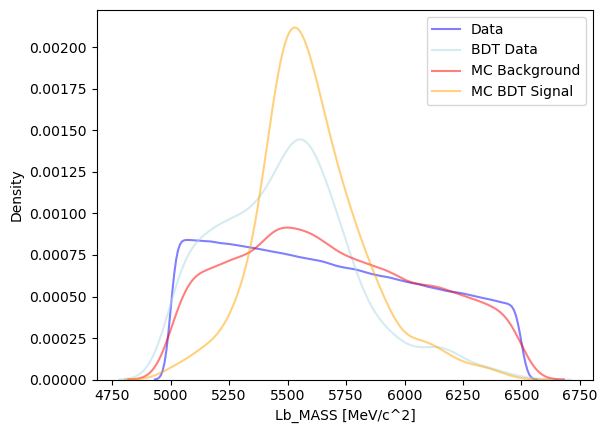

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Filtrar los datos según el criterio prob1 > 0.99
signal_filtered = data24_candidates.query('prob1 > 0.99')
mc_filtered = mc_signal_background.query('prob1 > 0.99')

fill = False

# Crear la figura y los ejes
fig, ax = plt.subplots()

# Graficar las distribuciones normalizadas usando seaborn kdeplot
sns.kdeplot(signal_data['Lb_MASS'], ax=ax, label='Data', color='blue', fill=fill, alpha=0.5)
sns.kdeplot(signal_filtered['Lb_MASS'], ax=ax, label='BDT Data', color='lightblue', fill=fill, alpha=0.5)
sns.kdeplot(mc_signal_background.query('(L_BKGCAT !=0)')['Lb_MASS'], ax=ax, label='MC Background', color='red', fill=fill, alpha=0.5)
sns.kdeplot(mc_filtered.query('(L_BKGCAT !=0)')['Lb_MASS'], ax=ax, label='MC BDT Signal', color='orange', fill=fill, alpha=0.5)

# Ajustar las etiquetas y la leyenda
ax.set_xlabel('Lb_MASS [MeV/c^2]')
ax.set_ylabel('Density')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend()

# Mostrar el gráfico
plt.show()


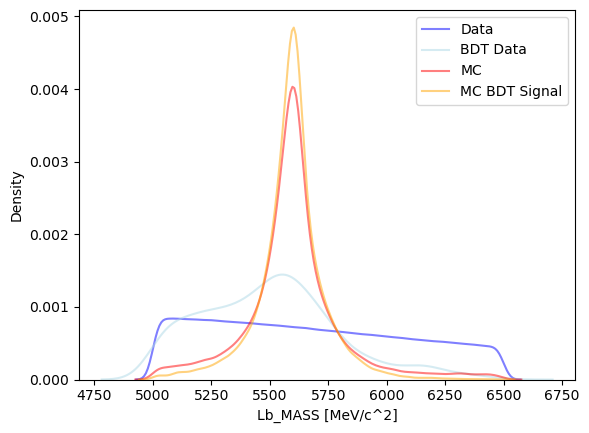

In [13]:
# Filtrar los datos según el criterio prob1 > 0.99
signal_filtered = data24_candidates.query('prob1 > 0.99')
mc_filtered = mc_signal_background.query('prob1 > 0.99')


fill = False

# Crear la figura y los ejes
fig, ax = plt.subplots()

# Graficar las distribuciones normalizadas usando seaborn kdeplot
sns.kdeplot(data24_candidates['Lb_MASS'], ax=ax, label='Data', color='blue', fill=fill, alpha=0.5)
sns.kdeplot(signal_filtered['Lb_MASS'], ax=ax, label='BDT Data', color='lightblue', fill=fill, alpha=0.5)
sns.kdeplot(mc_signal_background.query('(L_BKGCAT ==0)')['Lb_MASS'], ax=ax, label='MC', color='red', fill=fill, alpha=0.5)
sns.kdeplot(mc_filtered['Lb_MASS'], ax=ax, label='MC BDT Signal', color='orange', fill=fill, alpha=0.5)

# Ajustar las etiquetas y la leyenda
ax.set_xlabel('Lb_MASS [MeV/c^2]')
ax.set_ylabel('Density')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend()

# Mostrar el gráfico
plt.show()


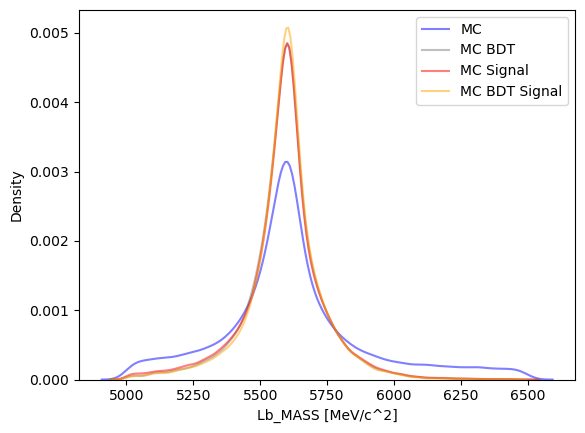

In [14]:
# Filtrar los datos según el criterio prob1 > 0.99
signal_filtered = data24_candidates.query('prob1 > 0.99')
mc_filtered = mc_signal_background.query('prob1 > 0.99')


fill = False

# Crear la figura y los ejes
fig, ax = plt.subplots()

# Graficar las distribuciones normalizadas usando seaborn kdeplot
# sns.kdeplot(signal_data['Lb_MASS'], ax=ax, label='Data', color='blue', fill=fill, alpha=0.5)
# sns.kdeplot(signal_filtered['Lb_MASS'], ax=ax, label='BDT Data', color='lightblue', fill=fill, alpha=0.5)
sns.kdeplot(mc_signal_background['Lb_MASS'], ax=ax, label='MC', color='blue', fill=fill, alpha=0.5)
sns.kdeplot(mc_filtered['Lb_MASS'], ax=ax, label='MC BDT', color='grey', fill=fill, alpha=0.5)

sns.kdeplot(mc_signal_background.query('(Lb_BKGCAT ==0)')['Lb_MASS'], ax=ax, label='MC Signal', color='red', fill=fill, alpha=0.5)
sns.kdeplot(mc_filtered.query('(Lb_BKGCAT ==0)')['Lb_MASS'], ax=ax, label='MC BDT Signal', color='orange', fill=fill, alpha=0.5)

# Ajustar las etiquetas y la leyenda
ax.set_xlabel('Lb_MASS [MeV/c^2]')
ax.set_ylabel('Density')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend()

# Mostrar el gráfico
plt.show()


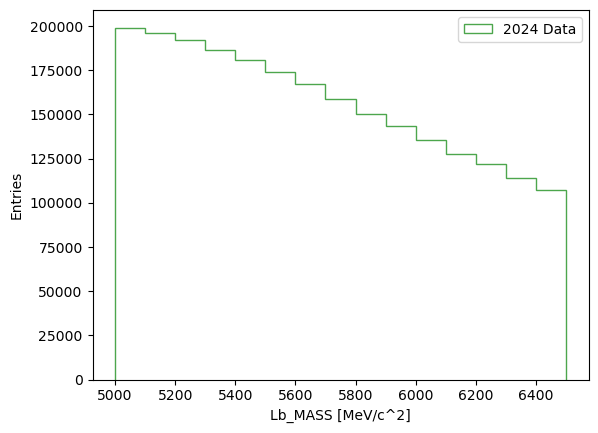

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()

# Plot histograms
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0)')['Lb_MASS'], bins=15, label='2024 Data', color='green', alpha=0.7, histtype='step')
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [16]:
print(model.feature_names_)

['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2', 'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT', 'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA', 'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ', 'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA', 'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2', 'xi_LbP', 'xi_LP']


In [17]:
print(mc_signal_background['xi_LbP'])

0        0.026965
1        0.018593
3        0.001145
4        0.004367
6        0.002367
           ...   
84570    0.055319
84572    0.024602
84573    0.041540
84574    0.015030
84579    0.014907
Name: xi_LbP, Length: 52660, dtype: float32


In [18]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(mc_signal_background)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_signal_background['prob1'] = signal_MVA_probs

[[9.99487340e-01 5.12660233e-04]
 [9.55922460e-03 9.90440775e-01]
 [1.51348832e-04 9.99848651e-01]
 ...
 [9.99979641e-01 2.03594487e-05]
 [9.94726365e-01 5.27363472e-03]
 [1.68351361e-02 9.83164864e-01]]


/tmp/javeser/ipykernel_5138/3195235424.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_background['prob1'] = signal_MVA_probs


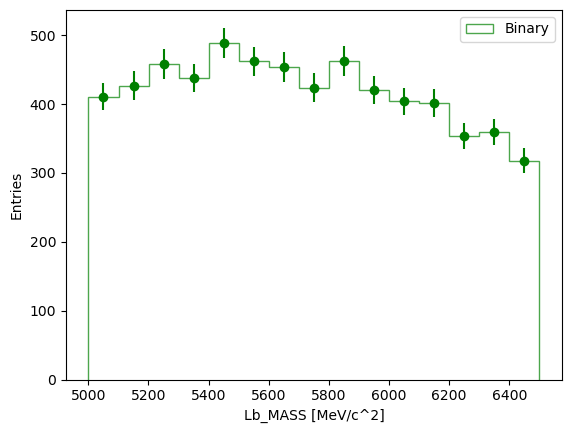

In [19]:


# Create the figure and axes
fig, axes = plt.subplots()
num_bins = 15
# Plot histograms
hist1, bins1, _ = axes.hist(mc_signal_background.query('(prob1 > 0.0) & (L_BKGCAT !=0)& (L_BKGCAT !=50)& (L_BKGCAT !=40)& (L_BKGCAT !=100)& (L_BKGCAT !=110)')['Lb_MASS'], bins=num_bins, label='Binary', color='green', alpha=0.7, histtype='step')
# hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='green',
    # label='Binary Data',
    drawstyle='steps-mid'
)

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [20]:
Lb_data = signal_data.query('(prob1 > 0.99)')['Lb_MASS'].values
df = pd.DataFrame({'Lb_MASS': Lb_data})
df.to_csv('Lb_MASS_data.csv', index=False)

In [21]:
# import ROOT

# # Define the variable x
# x = ROOT.RooRealVar('x', 'x', 5000, 6600)

# # Create the mirrored variable using RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6600-x', ROOT.RooArgList(x))

# # Apply a linear transformation to xMirrored (if needed)
# # In this case, we are mirroring the value of x and then applying a transformation
# # Example: y = a * xMirrored + b, where a = -1 and b = 10
# a = ROOT.RooConstVar('a', 'slope', -1.0)
# b = ROOT.RooConstVar('b', 'offset', 10.0)

# # Create the linear transformation variable using RooFormulaVar
# linearTransformed = ROOT.RooFormulaVar('linearTransformed', '@0*@1 + @2', ROOT.RooArgList(a, xMirrored, b))



In [22]:
# import ROOT
# import pandas as pd

# # Filter the data according to your criteria
# filtered_data = mc_signal_background.query('(prob1 > 0.0) & (L_BKGCAT != 0) & (L_BKGCAT != 50) & (L_BKGCAT != 40) & (L_BKGCAT != 100) & (L_BKGCAT != 110)')['Lb_MASS']

# # Convert the filtered pandas Series to a RooDataSet
# x = ROOT.RooRealVar('x', 'x', 5000, 6600)
# data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))

# for mass in filtered_data:
#     x.setVal(mass)
#     data_list.add(ROOT.RooArgSet(x))

# # Create the mirrored variable using RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6600-x', ROOT.RooArgList(x))

# # Define the parameters for the signal
# sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 3.0, 0.0, 10.0)
# sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 0.3, 0.1, 10.0)

# # Define the parameter for the Argus background
# argpar = ROOT.RooRealVar('argpar', 'argpar', -0.5, -10., -0.01)

# # Build the Argus background PDF using RooFit.RooConst for the constant
# background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(9.0), argpar)

# # Perform extended ML fit of the composite PDF to toy data
# res = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Print the fit result
# res.Print()

# # Optional: print the definitions to verify
# x.Print()
# xMirrored.Print()
# sigmean.Print()
# sigwidth.Print()
# argpar.Print()
# background.Print()


In [23]:
# import ROOT
# import pandas as pd

# # Filter the data according to your criteria
# filtered_data = mc_signal_background.query('(prob1 > 0.0) & (L_BKGCAT != 0) & (L_BKGCAT != 50) & (L_BKGCAT != 40)')['Lb_MASS']

# # Convert the filtered pandas Series to a RooDataSet
# x = ROOT.RooRealVar('x', 'x', 5000, 6500)
# data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
# for mass in filtered_data:
#     x.setVal(mass)
#     data_list.add(ROOT.RooArgSet(x))

# # Create the mirrored variable using RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# # Define the parameter for the Argus background
# argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., -0.0)

# # Build the Argus background PDF using RooFit.RooConst for the constant
# background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(1600.0), argpar)

# # Perform extended ML fit of the composite PDF to toy data
# res = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Print the fit result
# res.Print()

# # Create a RooPlot to draw on
# xframe = x.frame()

# # Plot toy data and composite PDF overlaid
# data_list.plotOn(xframe)
# background.plotOn(xframe)
# background.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed))

# # Draw the plot
# canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
# xframe.Draw()
# canvas.Draw()

# # Optional: print the definitions to verify
# x.Print()
# xMirrored.Print()
# argpar.Print()
# background.Print()


In [24]:
# import ROOT
# import pandas as pd

# # Filter the data according to your criteria
# filtered_data = mc_signal_background.query('(prob1 > 0.0) & (L_BKGCAT != 0) & (L_BKGCAT != 50) & (L_BKGCAT != 40) & (L_BKGCAT != 100) & (L_BKGCAT != 110)')['Lb_MASS']
# filtered_mass = signal_data.query('(prob1 > 0.99)')['Lb_MASS']
# # Convert the filtered pandas Series to a RooDataSet
# x = ROOT.RooRealVar('x', 'x', 5000, 6500)
# data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
# for mass in filtered_mass:
#     x.setVal(mass)
#     data_list.add(ROOT.RooArgSet(x))

# # Create the mirrored variable using RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# # Define the parameter for the Argus background
# argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., -0.0)

# # Build the Argus background PDF using RooFit.RooConst for the constant
# background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(6500.0), argpar)

# # Perform extended ML fit of the composite PDF to toy data
# res = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Print the fit result
# res.Print()

# # Create a RooPlot to draw on
# xframe = x.frame()

# # Plot toy data and composite PDF overlaid
# data_list.plotOn(xframe)
# background.plotOn(xframe)
# background.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed))

# # Draw the plot
# canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
# xframe.Draw()
# canvas.Draw()

# # Optional: print the definitions to verify
# x.Print()
# xMirrored.Print()
# argpar.Print()
# background.Print()


In [25]:
# import ROOT
# import pandas as pd

# filtered_mass = signal_data.query('(prob1 > 0.99)')['Lb_MASS']

# # Convert the filtered pandas Series to a RooDataSet
# x = ROOT.RooRealVar('x', 'x', 5000, 6500)
# data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
# for mass in filtered_data:
#     x.setVal(mass)
#     data_list.add(ROOT.RooArgSet(x))

# # Create the mirrored variable using RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# # Define the parameters for the signal
# sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5400, 5700, 5600)  # Adjust initial values based on data range
# sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 10, 0.1, 100)   # Adjust initial values based on data range

# # Build the Gaussian signal PDF
# signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# # Define the parameter for the Argus background
# argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., 0.0)

# # Build the Argus background PDF using RooFit.RooConst for the constant
# background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(1500.0), argpar)

# # Construct a signal and background PDF
# nsig = ROOT.RooRealVar('nsig', 'nsig', 400, 0., 10000)
# nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 800, 0., 10000)
# model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# # Perform extended ML fit of the combined PDF to toy data
# res = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Print the fit result
# res.Print()

# # Create a RooPlot to draw on
# xframe = x.frame()

# # Plot toy data and composite PDF overlaid
# data_list.plotOn(xframe)
# model.plotOn(xframe)
# model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed))
# model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineColor(ROOT.kRed))

# # Draw the plot
# canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
# xframe.Draw()
# canvas.Draw()

# # Optional: print the definitions to verify
# x.Print()
# xMirrored.Print()
# sigmean.Print()
# sigwidth.Print()
# argpar.Print()
# nsig.Print()
# nbkg.Print()
# model.Print()


Welcome to JupyROOT 6.30/04
[#1] INFO:NumericIntegration -- RooRealIntegral::init(background_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions have been identified as constant and will be precalculated and cached: (x_mirrored)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:NumericIntegration -- RooRealIntegral::init(background_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activ

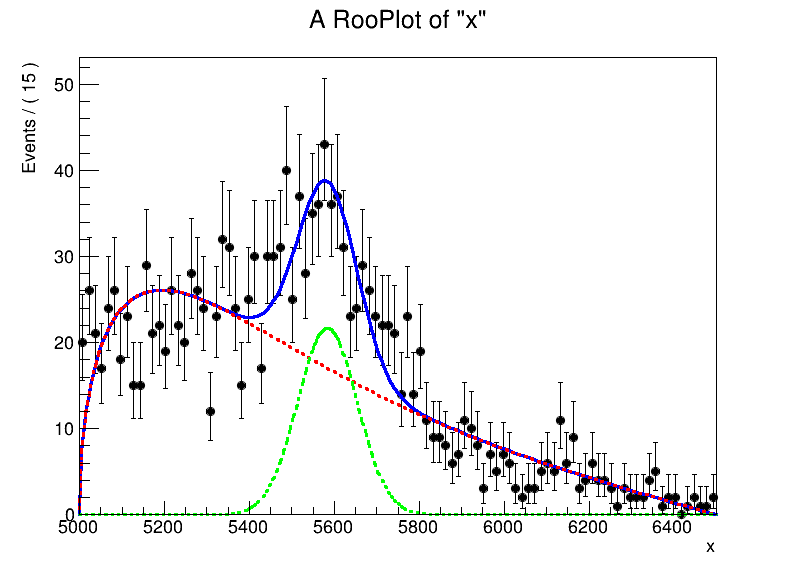

In [26]:
import ROOT
import pandas as pd

filtered_mass = data24_candidates.query('(prob1 > 0.98)')['Lb_MASS']

# Convert the filtered pandas Series to a RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Create the mirrored variable using RooFormulaVar
xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# Define the parameters for the signal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5620, 5550, 5630)  # Adjust initial values based on data range
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 60, 50, 70)   # Adjust initial values based on data range

# Build the Gaussian signal PDF
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define the parameter for the Argus background
argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., 0.0)

# Build the Argus background PDF using RooFit.RooConst for the constant
background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(1500), argpar)

# Perform the background fit
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Perform the signal fit
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construct a signal and background PDF
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Perform the total fit
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Print the fit results
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Create a RooPlot to draw on
xframe = x.frame()

# Plot toy data and composite PDF overlaid
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Draw the plot
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()

# Optional: print the definitions to verify
x.Print()
xMirrored.Print()
sigmean.Print()
sigwidth.Print()
argpar.Print()
nsig.Print()
nbkg.Print()
model.Print()


In [27]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = data24_candidates.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = data24_candidates.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

data24_candidates = pd.concat([data24_candidates,vertex_values],axis='columns')
data24_candidates = pd.concat([data24_candidates,vertex_values2],axis='columns')

FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [28]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = data24_candidates.query(particulas)
mc_signal2 = data24_candidates.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar columnas para almacenar los resultados
data24_candidates['alpha'] = np.nan
data24_candidates['pT'] = np.nan
data24_candidates['alpha_anti'] = np.nan
data24_candidates['pT_anti'] = np.nan

data24_candidates['p_inv_MASS_part'] = np.nan
data24_candidates['pim_inv_MASS_part'] = np.nan
data24_candidates['L_inv_MASS_part'] = np.nan

data24_candidates['p_inv_MASS_anti'] = np.nan
data24_candidates['pim_inv_MASS_anti'] = np.nan
data24_candidates['L_inv_MASS_anti'] = np.nan

particle = True

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    data24_candidates.at[index, 'alpha'] = alpha
    data24_candidates.at[index, 'pT'] = pT
    invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    data24_candidates.at[index, 'p_inv_MASS_part'] = invariant_mass_proton
    data24_candidates.at[index, 'pim_inv_MASS_part'] = invariant_mass_pion
    data24_candidates.at[index, 'L_inv_MASS_part'] = invariant_mass

particle = False
for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    data24_candidates.at[index, 'alpha_anti'] = alpha
    data24_candidates.at[index, 'pT_anti'] = pT
    invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    data24_candidates.at[index, 'p_inv_MASS_anti'] = invariant_mass_proton
    data24_candidates.at[index, 'pim_inv_MASS_anti'] = invariant_mass_pion
    data24_candidates.at[index, 'L_inv_MASS_anti'] = invariant_mass

# Combine alpha and alpha_anti into a single column without overwriting
data24_candidates['alpha_combined'] = data24_candidates['alpha'].combine_first(data24_candidates['alpha_anti'])
data24_candidates['pT_combined'] = data24_candidates['pT'].combine_first(data24_candidates['pT_anti'])

data24_candidates['p_inv_MASS'] =  data24_candidates['p_inv_MASS_part'].combine_first(data24_candidates['p_inv_MASS_anti'])
data24_candidates['pim_inv_MASS'] =  data24_candidates['pim_inv_MASS_part'].combine_first(data24_candidates['pim_inv_MASS_anti'])
data24_candidates['L_inv_MASS'] =  data24_candidates['L_inv_MASS_part'].combine_first(data24_candidates['L_inv_MASS_anti'])

# Mostrar resultados
print("Datos actualizados:")
print(data24_candidates[['alpha_combined', 'pT_combined']].dropna())


Datos actualizados:
         alpha_combined  pT_combined
0             -0.749566   472.611671
1              0.733453   643.697434
2             -0.732493   719.870238
3              0.736426   596.136449
4              0.737372    28.297652
...                 ...          ...
2385519       -0.072364   338.360775
2385520       -0.567747   261.950988
2385521        0.821228   210.534975
2385523        0.242069   287.617964
2385524        0.655139   526.536158

[1754865 rows x 2 columns]


[#1] INFO:NumericIntegration -- RooRealIntegral::init(background_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions have been identified as constant and will be precalculated and cached: (x_mirrored)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:NumericIntegration -- RooRealIntegral::init(background_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


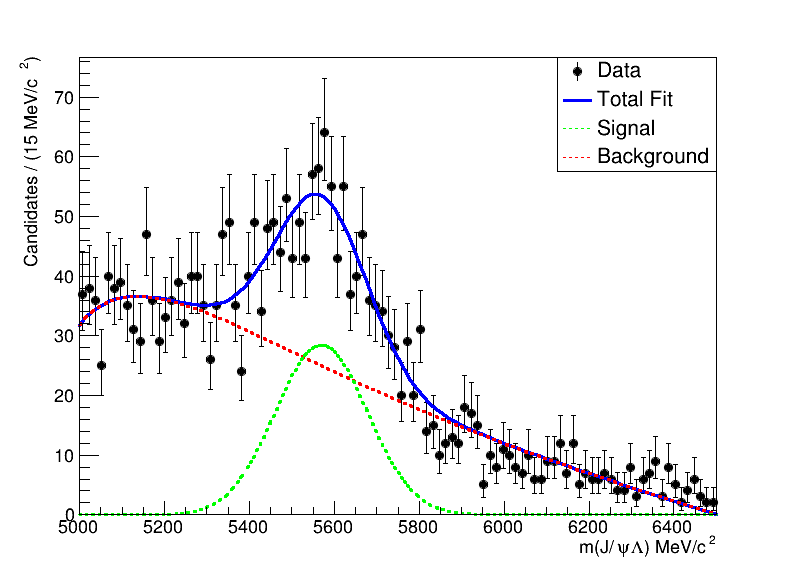

In [29]:
import ROOT
import pandas as pd

filtered_mass = data24_candidates.loc[(abs(data24_candidates['alpha_combined']) > 0.45) & (data24_candidates['prob1'] > 0.95), 'Lb_MASS']

# Convert the filtered pandas Series to a RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Create the mirrored variable using RooFormulaVar
xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# Define the parameters for the signal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)  # Adjust initial values based on data range
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)   # Adjust initial values based on data range

# Build the Gaussian signal PDF
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define the parameter for the Argus background
argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., 0.0)

# Build the Argus background PDF using RooFit.RooConst for the constant
background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(1600), argpar)

# Perform the background fit
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Perform the signal fit
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construct a signal and background PDF
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Perform the total fit
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Print the fit results
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Create a RooPlot to draw on
xframe = x.frame()

# Plot toy data and composite PDF overlaid
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Set the title for the x-axis and y-axis, remove the general title
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")


# Crear una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# Ajustar el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajustar el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajustar el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line2 = ROOT.TLine()
signal_line2.SetLineColor(ROOT.kRed)
signal_line2.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line2, "Background", "l")


# Draw the plot
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Optional: print the definitions to verify
x.Print()
xMirrored.Print()
sigmean.Print()
sigwidth.Print()
argpar.Print()
nsig.Print()
nbkg.Print()
model.Print()


In [30]:
# RooRealVar::x = 5071.23  L(5000 - 6500) 
# RooFormulaVar::x_mirrored[ actualVars=(x) formula="6500-x[0]" ] = 1428.77
# RooRealVar::sigmean = 5558.33 +/- 7.41777  L(5500 - 5650) 
# RooRealVar::sigwidth = 125.192 +/- 7.63991  L(100 - 400) 
# RooRealVar::argpar = -0.830411 +/- 0.0821052  L(-10 - 0) 
# RooRealVar::nsig = 1100.98 +/- 74.4254  L(100 - 20000) 
# RooRealVar::nbkg = 2475.97 +/- 83.1504  L(100 - 20000) 
# RooAddPdf::model[ nsig * signal + nbkg * background ] = 278.825/1 

In [31]:
# RooRealVar::x = 6212.2  L(5000 - 6500) 
# RooFormulaVar::x_mirrored[ actualVars=(x) formula="6500-x[0]" ] = 287.797
# RooRealVar::sigmean = 5561.63 +/- 8.35156  L(5500 - 5650) 
# RooRealVar::sigwidth = 127.577 +/- 8.74236  L(100 - 400) 
# RooRealVar::argpar = -0.937951 +/- 0.115469  L(-10 - 0) 
# RooRealVar::nsig = 783.395 +/- 58.1248  L(100 - 20000) 
# RooRealVar::nbkg = 1280.6 +/- 62.2538  L(100 - 20000) 
# RooAddPdf::model[ nsig * signal + nbkg * background ] = 71.0059/1

ajuste con crytal ball

In [32]:
# import ROOT
# import pandas as pd

# # Filtrar los datos (asegúrate de definir signal_data antes de este paso)
# filtered_mass = signal_data.loc[(abs(signal_data['alpha_combined']) > 0.45) & (signal_data['prob1'] > 0.95), 'Lb_MASS']

# # Convertir los valores filtrados de masa en un RooDataSet
# x = ROOT.RooRealVar('x', 'x', 5000, 6500)
# data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
# for mass in filtered_mass:
#     x.setVal(mass)
#     data_list.add(ROOT.RooArgSet(x))

# # Crear la variable espejada usando RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# # Definir los parámetros para la señal con Crystal Ball
# sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5620, 5500, 5650)  # Ajustar valores iniciales según el rango de datos
# sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 150, 100, 400)  # Ajustar valores iniciales según el rango de datos
# alpha = ROOT.RooRealVar('alpha', 'alpha', 0.5, 0.5, 1.0)  # Parámetro de cola de potencia
# n = ROOT.RooRealVar('n', 'n', 5.0, 0.5, 10.0)  # Parámetro de desplazamiento

# # Construir el modelo de señal Crystal Ball
# signalModel = ROOT.RooCBShape('signal', 'signal', x, sigmean, sigwidth, alpha, n)

# # Definir el parámetro para el fondo de Argus
# argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., 0.0)

# # Construir el modelo de fondo Argus utilizando RooFit.RooConst para la constante
# background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(1500), argpar)

# # Realizar el ajuste al fondo
# background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Realizar el ajuste a la señal
# signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Construir el PDF combinado de señal y fondo
# nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
# nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
# model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# # Realizar el ajuste total
# total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Imprimir los resultados del ajuste
# background_fit_result.Print()
# signal_fit_result.Print()
# total_fit_result.Print()

# # Crear un RooPlot para dibujar
# xframe = x.frame()

# # Graficar los datos y el PDF compuesto superpuesto
# data_list.plotOn(xframe)
# model.plotOn(xframe)
# model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
# model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# # Establecer el título para los ejes x e y, eliminar el título general
# xframe.SetTitle("")
# xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
# xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# # Crear una leyenda
# legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# # Ajustar el estilo de los puntos de la leyenda a círculos
# data_marker = ROOT.TMarker()
# data_marker.SetMarkerStyle(ROOT.kFullCircle)
# legend.AddEntry(data_marker, "Data", "pe")
# legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# # Ajustar el estilo de la línea de la leyenda para la señal a verde y discontinua
# signal_line = ROOT.TLine()
# signal_line.SetLineColor(ROOT.kGreen)
# signal_line.SetLineStyle(ROOT.kDashed)
# legend.AddEntry(signal_line, "Signal", "l")

# # Ajustar el estilo de la línea de la leyenda para el fondo a rojo y discontinua
# background_line = ROOT.TLine()
# background_line.SetLineColor(ROOT.kRed)
# background_line.SetLineStyle(ROOT.kDashed)
# legend.AddEntry(background_line, "Background", "l")

# # Dibujar el gráfico
# canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
# xframe.Draw()
# legend.Draw()
# canvas.Draw()

# # Opcional: imprimir las definiciones para verificar
# x.Print()
# xMirrored.Print()
# sigmean.Print()
# sigwidth.Print()
# alpha.Print()
# n.Print()
# argpar.Print()
# nsig.Print()
# nbkg.Print()
# model.Print()


In [33]:
# RooRealVar::x = 5071.23  L(5000 - 6500) 
# RooFormulaVar::x_mirrored[ actualVars=(x) formula="6500-x[0]" ] = 1428.77
# RooRealVar::sigmean = 5559.81 +/- 11.0362  L(5500 - 5650) 
# RooRealVar::sigwidth = 114.155 +/- 10.3698  L(100 - 400) 
# RooRealVar::alpha = 0.71185 +/- 0.0842234  L(0.5 - 1) 
# RooRealVar::n = 0.5 +/- 0.247634  L(0.5 - 10) 
# RooRealVar::argpar = -2.25803e-06 +/- 0.0602714  L(-10 - 0) 
# RooRealVar::nsig = 2026.87 +/- 110.895  L(100 - 20000) 
# RooRealVar::nbkg = 3777.08 +/- 118.522  L(100 - 20000) 
# RooAddPdf::model[ nsig * signal + nbkg * background ] = 283.229/1

Ajuste de neural data after BDT

In [34]:
# # Cargar el modelo entrenado
# mlp = joblib.load('neural_network.pkl')
# # Suponiendo que data24_selected ya está definido
# data24_selected_nan = signal_data.dropna()

# scaler = StandardScaler()
# data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

# maxima_probabilidad = 0.9999999999999999

# # Predecir probabilidades en el nuevo conjunto de datos
# y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# # Filtrar los datos que cumplan con la condición
# high_confidence_indices = y_pred > maxima_probabilidad
# high_confidence_data = data24_selected_nan[high_confidence_indices]

# # Guardar los datos en un archivo CSV
# high_confidence_data.to_csv('Neural_network_data.csv', index=False)


In [35]:
model = CatBoostClassifier().load_model("new_BDT_full_range")
# prob = model.predict_proba(mc_signal_background)
# print(prob)

# signal_MVA_prob_eval = prob
# signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
# mc_signal_background['prob1'] = signal_MVA_probs

In [36]:

# # Cargar los datos desde el archivo CSV
# neural_data = pd.read_csv('Neural_network_data.csv')

# # Ahora puedes trabajar con high_confidence_data
# maxima_probabilidad = 0.95
# filtro = model.predict_proba(neural_data)[:,1] >= maxima_probabilidad
# neural_data_signal = neural_data[filtro]
# neural_data_bkg = neural_data[filtro]
# print(neural_data.shape)

In [37]:
# from rk_transport import FarRKTrkTransport, propagate_to_vertex

# def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
#     xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
#     mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
#     return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

# rk = FarRKTrkTransport()

# vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
# vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

# vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = neural_data_signal.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
# vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = neural_data_signal.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

# neural_data_signal = pd.concat([neural_data_signal,vertex_values],axis='columns')
# neural_data_signal = pd.concat([neural_data_signal,vertex_values2],axis='columns')

In [38]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
# antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

# mc_signal1 = neural_data_signal.query(particulas)
# mc_signal2 = neural_data_signal.query(antiparticulas)

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector 
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     total_momentum = pplus_4 + pminus_4
#     pV0 = total_momentum.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Inicializar columnas para almacenar los resultados
# signal_data['alpha'] = np.nan
# signal_data['pT'] = np.nan
# signal_data['alpha_anti'] = np.nan
# signal_data['pT_anti'] = np.nan

# signal_data['p_inv_MASS_part'] = np.nan
# signal_data['pim_inv_MASS_part'] = np.nan
# signal_data['L_inv_MASS_part'] = np.nan

# signal_data['p_inv_MASS_anti'] = np.nan
# signal_data['pim_inv_MASS_anti'] = np.nan
# signal_data['L_inv_MASS_anti'] = np.nan

# particle = True

# for index, row in mc_signal1.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     signal_data.at[index, 'alpha'] = alpha
#     signal_data.at[index, 'pT'] = pT
#     invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     signal_data.at[index, 'p_inv_MASS_part'] = invariant_mass_proton
#     signal_data.at[index, 'pim_inv_MASS_part'] = invariant_mass_pion
#     signal_data.at[index, 'L_inv_MASS_part'] = invariant_mass

# particle = False
# for index, row in mc_signal2.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     signal_data.at[index, 'alpha_anti'] = alpha
#     signal_data.at[index, 'pT_anti'] = pT
#     invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     signal_data.at[index, 'p_inv_MASS_anti'] = invariant_mass_proton
#     signal_data.at[index, 'pim_inv_MASS_anti'] = invariant_mass_pion
#     signal_data.at[index, 'L_inv_MASS_anti'] = invariant_mass

# # Combine alpha and alpha_anti into a single column without overwriting
# signal_data['alpha_combined'] = signal_data['alpha'].combine_first(signal_data['alpha_anti'])
# signal_data['pT_combined'] = signal_data['pT'].combine_first(signal_data['pT_anti'])

# signal_data['p_inv_MASS'] =  signal_data['p_inv_MASS_part'].combine_first(signal_data['p_inv_MASS_anti'])
# signal_data['pim_inv_MASS'] =  signal_data['pim_inv_MASS_part'].combine_first(signal_data['pim_inv_MASS_anti'])
# signal_data['L_inv_MASS'] =  signal_data['L_inv_MASS_part'].combine_first(signal_data['L_inv_MASS_anti'])

# # Mostrar resultados
# print("Datos actualizados:")
# print(signal_data[['alpha_combined', 'pT_combined']].dropna())


In [39]:
# import ROOT
# import pandas as pd

# # filtered_mass = neural_data_signal.loc[ (neural_data_signal['prob'] > 0.95), 'Lb_MASS']
# filtered_mass = neural_data_signal['Lb_MASS']
# # Convert the filtered pandas Series to a RooDataSet
# x = ROOT.RooRealVar('x', 'x', 5000, 6500)
# data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
# for mass in filtered_mass:
#     x.setVal(mass)
#     data_list.add(ROOT.RooArgSet(x))

# # Create the mirrored variable using RooFormulaVar
# xMirrored = ROOT.RooFormulaVar('x_mirrored', '6500-x', ROOT.RooArgList(x))

# # Define the parameters for the signal
# sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5620, 5500, 5650)  # Adjust initial values based on data range
# sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 150, 100, 400)   # Adjust initial values based on data range

# # Build the Gaussian signal PDF
# signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# # Define the parameter for the Argus background
# argpar = ROOT.RooRealVar('argpar', 'argpar', -0.3, -10., 0.0)

# # Build the Argus background PDF using RooFit.RooConst for the constant
# background = ROOT.RooArgusBG('background', 'background', xMirrored, ROOT.RooFit.RooConst(1500), argpar)

# # Perform the background fit
# background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Perform the signal fit
# signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Construct a signal and background PDF
# nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
# nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
# model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# # Perform the total fit
# total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# # Print the fit results
# background_fit_result.Print()
# signal_fit_result.Print()
# total_fit_result.Print()

# # Create a RooPlot to draw on
# xframe = x.frame()

# # Plot toy data and composite PDF overlaid
# data_list.plotOn(xframe)
# model.plotOn(xframe)
# model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
# model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# # Set the title for the x-axis and y-axis, remove the general title
# xframe.SetTitle("")
# xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
# xframe.SetYTitle("Candidates / (15 MeV/c^{2})")


# # Crear una leyenda
# legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# # Ajustar el estilo de los puntos de la leyenda a círculos
# data_marker = ROOT.TMarker()
# data_marker.SetMarkerStyle(ROOT.kFullCircle)
# legend.AddEntry(data_marker, "Data", "pe")
# legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# # Ajustar el estilo de la línea de la leyenda para la señal a verde y discontinua
# signal_line = ROOT.TLine()
# signal_line.SetLineColor(ROOT.kGreen)
# signal_line.SetLineStyle(ROOT.kDashed)
# legend.AddEntry(signal_line, "Signal", "l")

# # Ajustar el estilo de la línea de la leyenda para la señal a verde y discontinua
# signal_line2 = ROOT.TLine()
# signal_line2.SetLineColor(ROOT.kRed)
# signal_line2.SetLineStyle(ROOT.kDashed)
# legend.AddEntry(signal_line2, "Background", "l")


# # Draw the plot
# canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
# xframe.Draw()
# canvas.Draw()
# legend.Draw()

# # Optional: print the definitions to verify
# x.Print()
# xMirrored.Print()
# sigmean.Print()
# sigwidth.Print()
# argpar.Print()
# nsig.Print()
# nbkg.Print()
# model.Print()


RooRealVar::x = 5818.79  L(5000 - 6500) 
RooFormulaVar::x_mirrored[ actualVars=(x) formula="6500-x[0]" ] = 681.211
RooRealVar::sigmean = 5546.91 +/- 4.75743  L(5500 - 5650) 
RooRealVar::sigwidth = 169.656 +/- 5.31285  L(100 - 400) 
RooRealVar::argpar = -3.01164e-11 +/- 0.0568433  L(-10 - 0) 
RooRealVar::nsig = 1896.64 +/- 70.0248  L(100 - 20000) 
RooRealVar::nbkg = 525.32 +/- 59.4305  L(100 - 20000) 
RooAddPdf::model[ nsig * signal + nbkg * background ] = 131.855/1